--- Pourcentage de valeurs manquantes par colonne (> 0%) ---
construction     80.767507
fatality         72.272642
sic_code         65.535014
visibility       31.273576
occ_code         11.985061
wind_speed        7.084967
main              7.084967
wind_deg          7.084967
temp              7.084967
humidity          7.084967
pressure          7.084967
feels_like        7.084967
description       7.084967
clouds            7.084967
sex_x             3.747899
event_keyword     0.224090
city_x            0.024276
zip_x             0.011204
state_x           0.009337
abstract          0.001867
dtype: float64


--- Distribution numérique de degree_of_inj_x ---
degree_of_inj_x
2    48.500467
1    38.614379
3    12.786181
0     0.095238
4     0.003735
Name: proportion, dtype: float64




/tmp/ipykernel_17429/2067554329.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='degree_of_inj_x', palette='viridis')


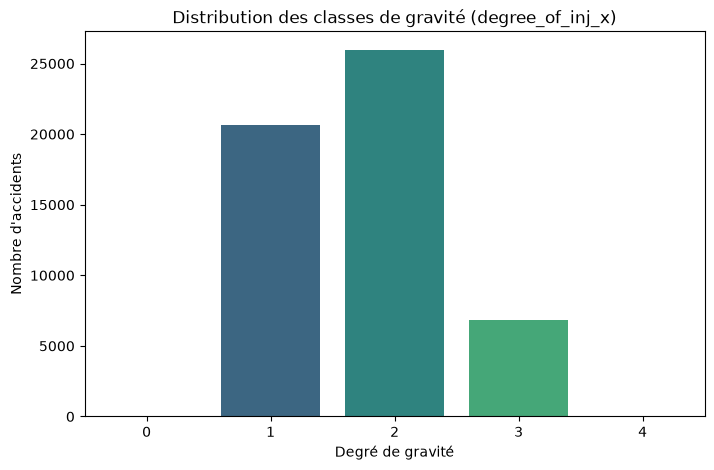

--- Distribution de la variable 'fatality' ---
fatality
NaN    38702
X      14848
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
file_path = "/home/hado/Projets/Projet_vinci_adt/Data/raw/Injury Severity.xlsx"
df = pd.read_excel(file_path)

# 1. Calcul du pourcentage de valeurs manquantes
missing_perc = df.isnull().mean() * 100
print("--- Pourcentage de valeurs manquantes par colonne (> 0%) ---")
print(missing_perc[missing_perc > 0].sort_values(ascending=False))
print("\n")

# 2. Analyse de la distribution de la variable cible
print("--- Distribution numérique de degree_of_inj_x ---")
print(df['degree_of_inj_x'].value_counts(normalize=True) * 100)
print("\n")

# 3. Visualisation de la cible
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='degree_of_inj_x', palette='viridis')
plt.title("Distribution des classes de gravité (degree_of_inj_x)")
plt.ylabel("Nombre d'accidents")
plt.xlabel("Degré de gravité")
plt.show()

# 4. Vérification de la variable 'fatality'
print("--- Distribution de la variable 'fatality' ---")
print(df['fatality'].value_counts(dropna=False))

In [2]:
# Variables catégorielles ou discrètes à inspecter
colonnes_a_inspecter = ['degree_of_inj_x', 'fatality', 'event_type', 'construction']

for col in colonnes_a_inspecter:
    print(f"--- Modalités et fréquences pour : {col} ---")
    # Affiche les valeurs uniques, leur compte, et inclut les valeurs NaN (manquantes)
    print(df[col].value_counts(dropna=False))
    print("\n")

--- Modalités et fréquences pour : degree_of_inj_x ---
degree_of_inj_x
2    25972
1    20678
3     6847
0       51
4        2
Name: count, dtype: int64


--- Modalités et fréquences pour : fatality ---
fatality
NaN    38702
X      14848
Name: count, dtype: int64


--- Modalités et fréquences pour : event_type ---
event_type
2     12784
14    10673
1     10650
5     10350
8      2034
13     1760
12     1737
6      1543
4      1427
10      152
3       148
7       129
9        57
11       56
0        50
Name: count, dtype: int64


--- Modalités et fréquences pour : construction ---
construction
NaN    43251
1.0    10299
Name: count, dtype: int64




In [9]:
# 1. Validation de la classe des décès
print("--- Croisement : degree_of_inj_x vs fatality ---")
crosstab_result = pd.crosstab(df['degree_of_inj_x'], df['fatality'].fillna('Non renseigné'))
print(crosstab_result)
print("\n")

# 2. Impact du filtre 'construction' sur la taille du dataset
df_construction_only = df[df['construction'] == 1.0]
print(f"Lignes restantes si on filtre uniquement sur construction == 1.0 : {len(df_construction_only)}")
print("\n")

# 3. Statistiques descriptives du texte (abstract) pour le futur NLP
if 'abstract' in df.columns:
    abstract_lengths = df['abstract'].dropna().astype(str).apply(len)
    print("--- Statistiques de longueur des textes (caractères) dans 'abstract' ---")
    print(abstract_lengths.describe())


--- Croisement : degree_of_inj_x vs fatality ---
fatality         Non renseigné      X
degree_of_inj_x                      
0                           51      0
1                         6356  14322
2                        25549    423
3                         6744    103
4                            2      0


Lignes restantes si on filtre uniquement sur construction == 1.0 : 10299


--- Statistiques de longueur des textes (caractères) dans 'abstract' ---
count    53549.000000
mean       460.993315
std        344.068822
min          1.000000
25%        256.000000
50%        363.000000
75%        541.000000
max       6632.000000
Name: abstract, dtype: float64
